# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Курс data analyst/Python/Візуалізація/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [ ]:
month_mean = df['count'].resample('ME').mean()

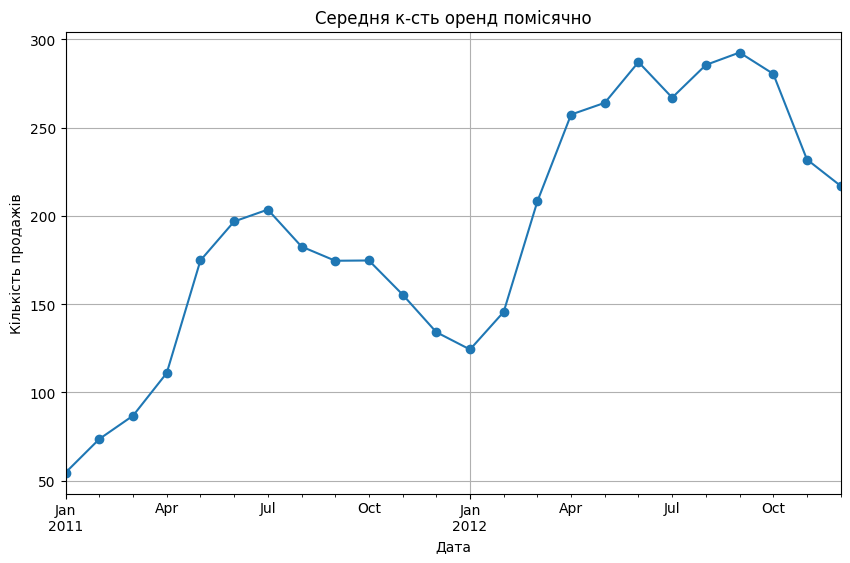

In [ ]:
month_mean.plot(
    kind='line',
    marker='o',
    figsize=(10,6),
    title = 'Середня к-сть оренд помісячно',
    xlabel = 'Дата',
    ylabel = 'Кількість продажів',
    grid = True
);

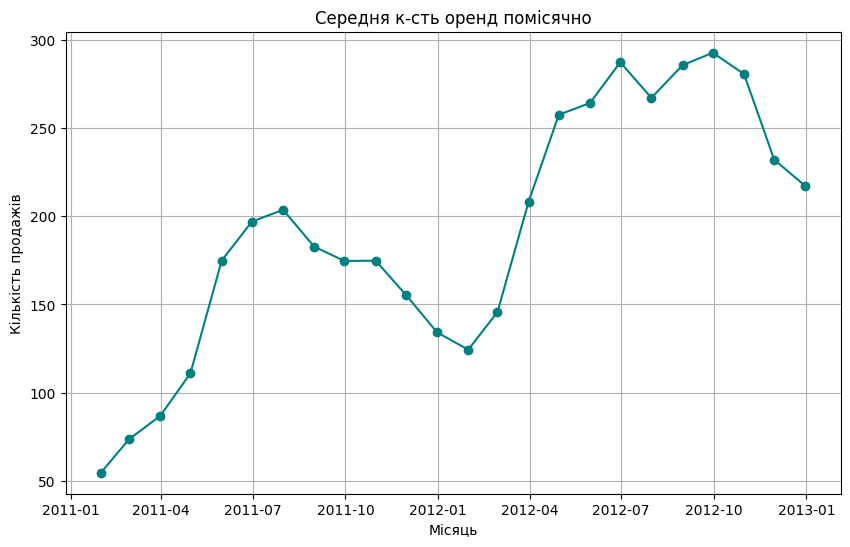

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(month_mean.index, month_mean.values, marker='o', color='teal', linestyle='-')
plt.title('Середня к-сть оренд помісячно')
plt.xlabel('Місяць')
plt.ylabel('Кількість продажів')
plt.grid(True)
plt.show()

Більше подобається другий графік, оскільки по осі Х більш зрозумілі позначки, не потрібно догадуватися який це рік.



## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [ ]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

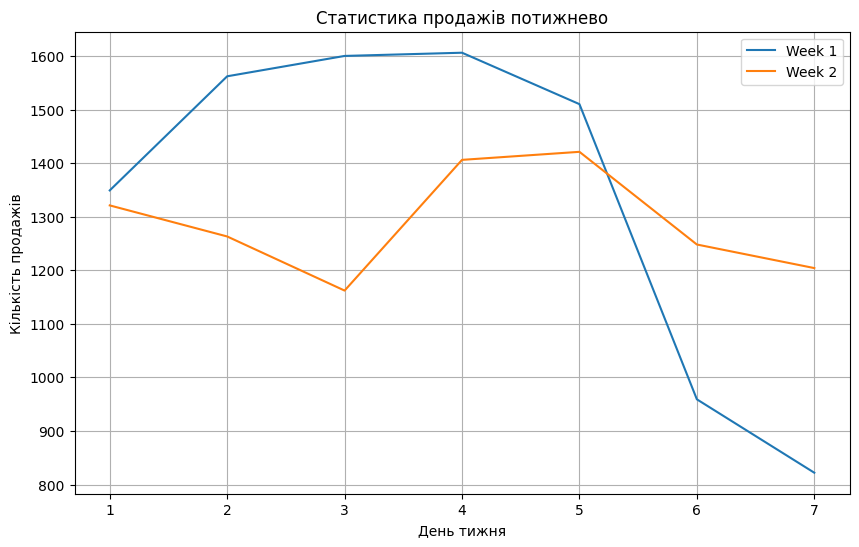

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(days, sales_week1, label = 'Week 1')
plt.plot(days, sales_week2, label = 'Week 2')

plt.title('Статистика продажів потижнево')
plt.xlabel('День тижня')
plt.ylabel('Кількість продажів')
plt.grid(True)
plt.legend()
plt.show()

Продажі булт помітно стабільнішими у тиждень 2.
Можемо подивитися на розмах:
Тиждень 1: 1606-822 = 784
Тиждень 2: 1421-1162 = 259 (розмах коливань втричі менший)

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [ ]:
temp_mean = df['temp'].resample('ME').mean()
season_mean = df.groupby('season')['count'].mean()

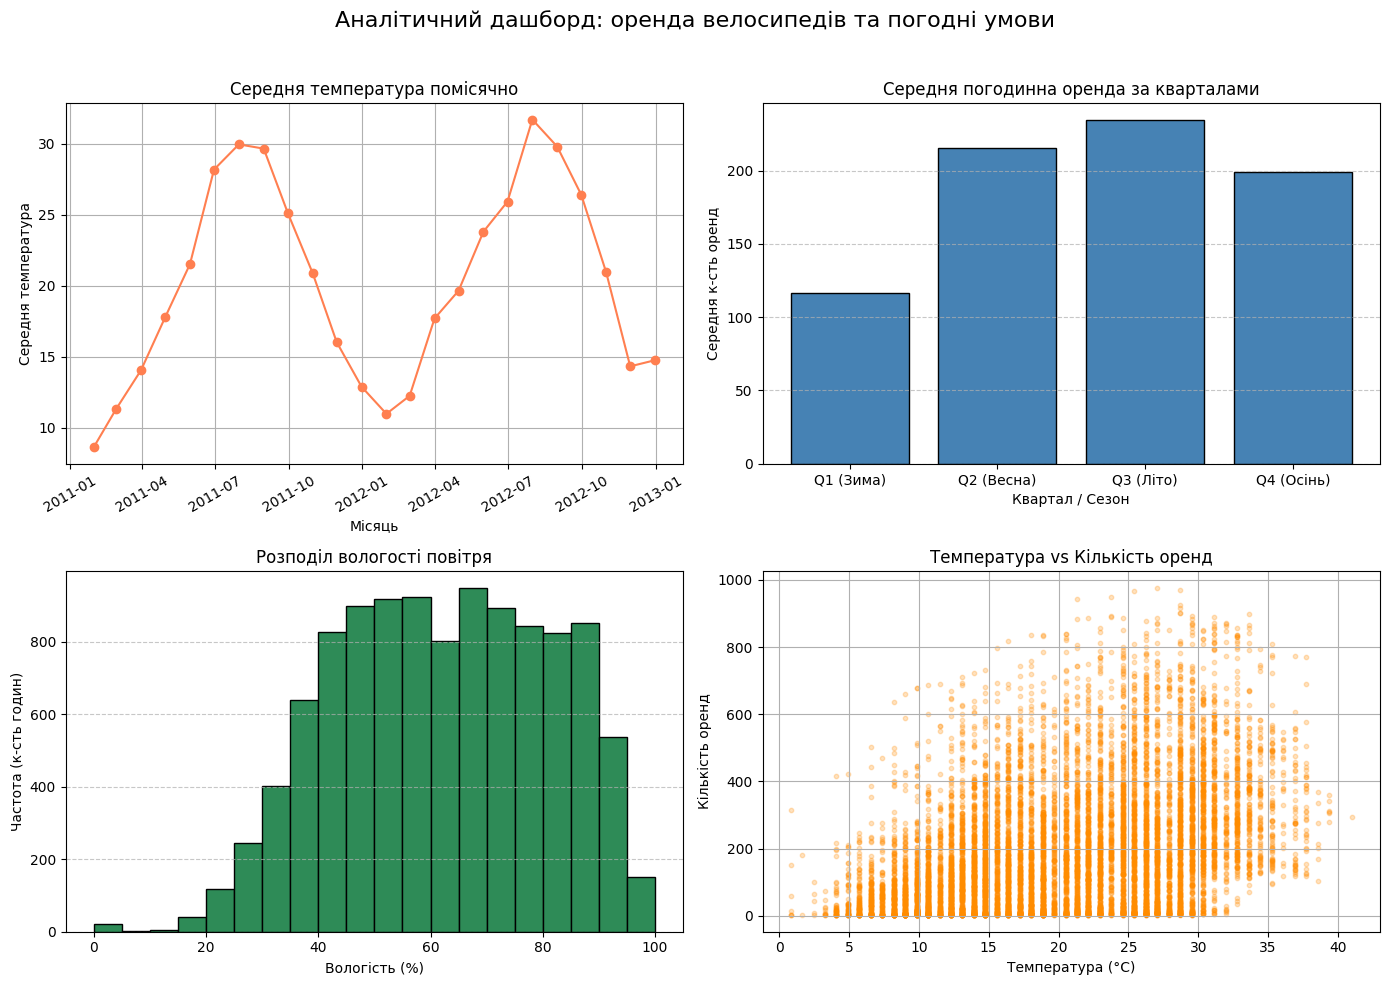

In [ ]:
plt.figure(figsize=(14,10))
plt.suptitle('Аналітичний дашборд: оренда велосипедів та погодні умови', fontsize=16, y=0.98)

plt.subplot(2, 2, 1)
plt.plot(temp_mean.index, temp_mean.values, color='coral', marker='o')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Середня температура')
plt.xticks(rotation=30)
plt.grid(True)

plt.subplot(2, 2, 2)
season_labels = ['Q1 (Зима)', 'Q2 (Весна)', 'Q3 (Літо)', 'Q4 (Осінь)']
plt.bar(season_labels, season_mean.values, color='steelblue', edgecolor='black')
plt.title('Середня погодинна оренда за кварталами')
plt.xlabel('Квартал / Сезон')
plt.ylabel('Середня к-сть оренд')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=20, color='seagreen', edgecolor='black')
plt.title('Розподіл вологості повітря')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота (к-сть годин)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.25, color='darkorange', s=10)
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')
plt.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

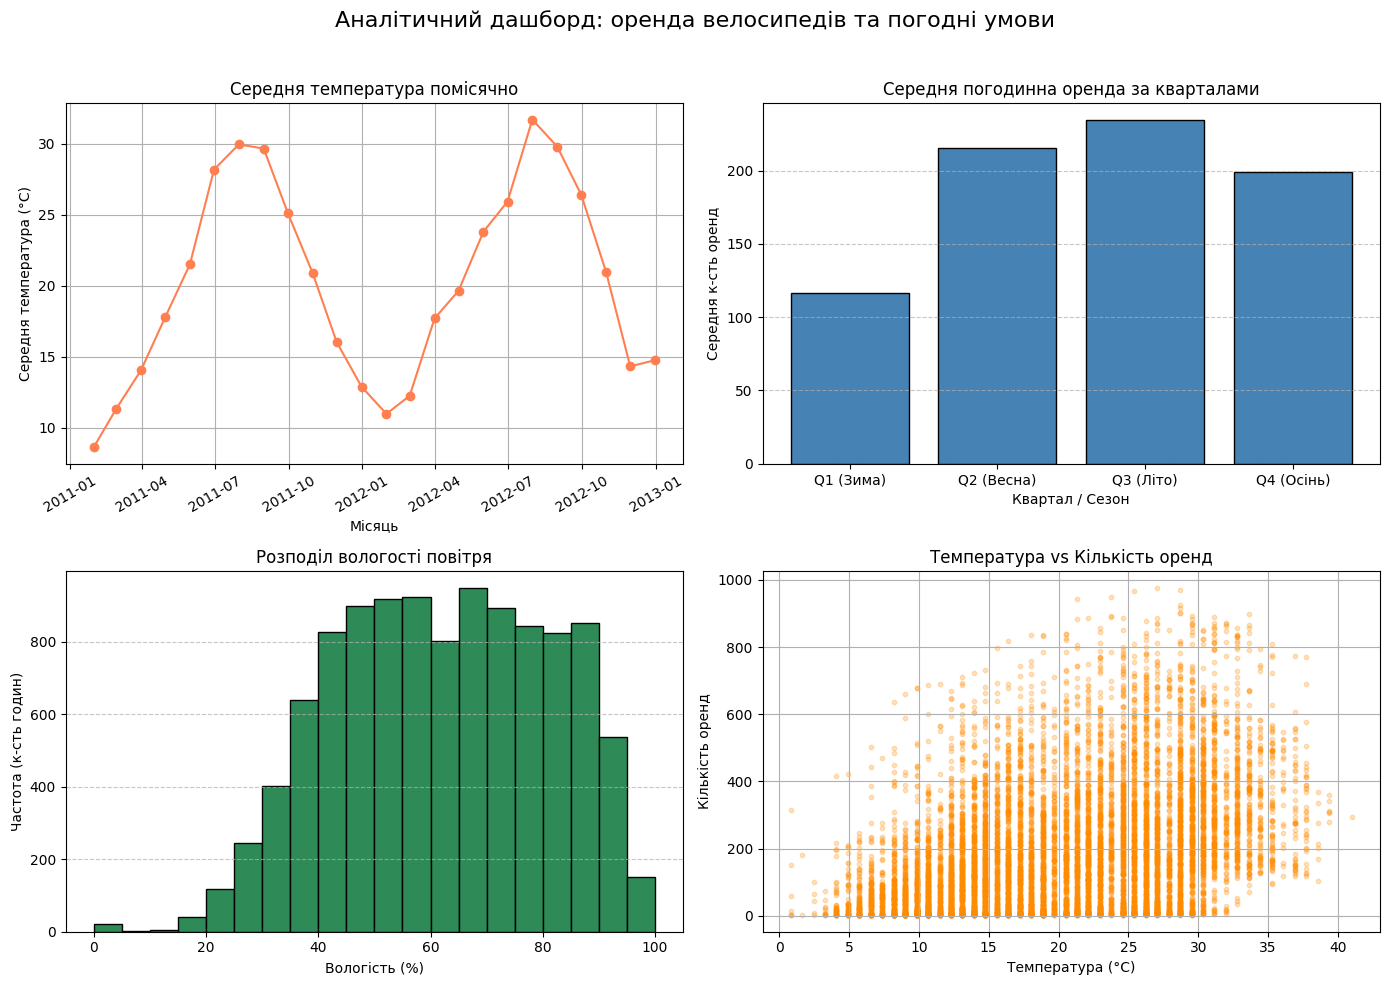

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Аналітичний дашборд: оренда велосипедів та погодні умови', fontsize=16, y=0.98)

ax[0, 0].plot(temp_mean.index, temp_mean.values, color='coral', marker='o')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Середня температура (°C)')
ax[0, 0].tick_params(axis='x', rotation=30)
ax[0, 0].grid(True)

season_labels = ['Q1 (Зима)', 'Q2 (Весна)', 'Q3 (Літо)', 'Q4 (Осінь)']
ax[0, 1].bar(season_labels, season_mean.values, color='steelblue', edgecolor='black')
ax[0, 1].set_title('Середня погодинна оренда за кварталами')
ax[0, 1].set_xlabel('Квартал / Сезон')
ax[0, 1].set_ylabel('Середня к-сть оренд')
ax[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

ax[1, 0].hist(df['humidity'], bins=20, color='seagreen', edgecolor='black')
ax[1, 0].set_title('Розподіл вологості повітря')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота (к-сть годин)')
ax[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

ax[1, 1].scatter(df['temp'], df['count'], alpha=0.25, color='darkorange', s=10)
ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренд')
ax[1, 1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.subplot() викликається послідовно для кожної комірки окремо, усі наступні команди автоматично застосовуються лише до останнього активованого графіка. Якщо потрібно повернутися до попереднього графіка і щось домалювати, доводиться знову викликати plt.subplot().
plt.subplots() створює всю сітку одразу одним рядком і повертає фігуру fig та двовимірний масив осей ax. До кожного графіка можна звертатися незалежно за індексами матриці в будь-якому порядку.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

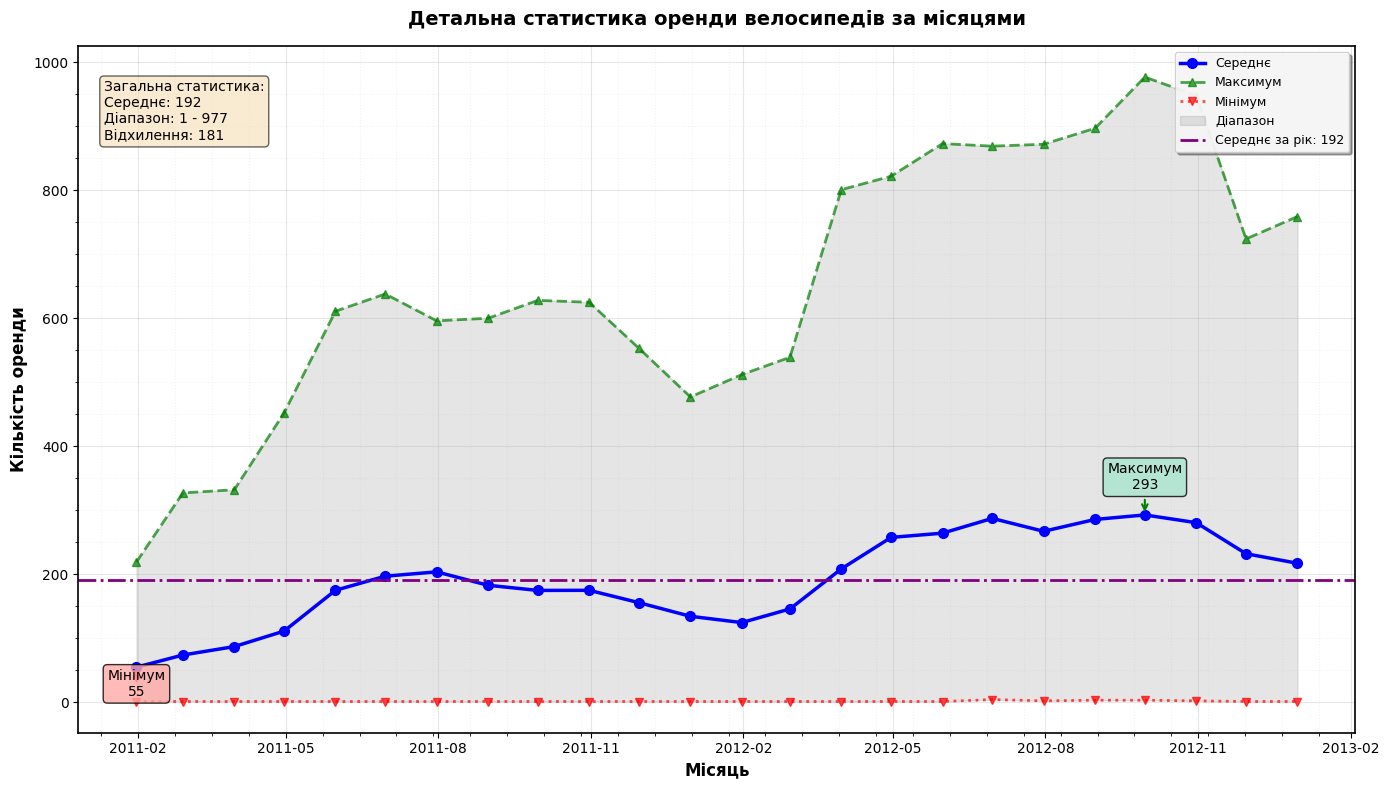

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

monthly_stats = df['count'].resample('ME').agg(['mean', 'max', 'min', 'std'])

overall_mean = df['count'].mean()
overall_min = df['count'].min()
overall_max = df['count'].max()
overall_std = df['count'].std()

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(
    monthly_stats.index,
    monthly_stats['mean'],
    'b-o',
    linewidth=2.5,
    label='Середнє',
    markersize=7,
)
ax.plot(
    monthly_stats.index,
    monthly_stats['max'],
    'g--^',
    linewidth=2,
    label='Максимум',
    markersize=6,
    alpha=0.7,
)
ax.plot(
    monthly_stats.index,
    monthly_stats['min'],
    'r:v',
    linewidth=2,
    label='Мінімум',
    markersize=6,
    alpha=0.7,
)

ax.fill_between(
    monthly_stats.index,
    monthly_stats['min'],
    monthly_stats['max'],
    alpha=0.2,
    color='gray',
    label='Діапазон',
)

max_mean_idx = monthly_stats['mean'].idxmax()
max_mean_val = monthly_stats['mean'].max()
ax.annotate(
    f'Максимум\n{max_mean_val:.0f}',
    xy=(max_mean_idx, max_mean_val),
    xytext=(max_mean_idx, max_mean_val + 40),
    arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
    fontsize=10,
    ha='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#a8e6cf', alpha=0.8),
)

min_mean_idx = monthly_stats['mean'].idxmin()
min_mean_val = monthly_stats['mean'].min()
ax.annotate(
    f'Мінімум\n{min_mean_val:.0f}',
    xy=(min_mean_idx, min_mean_val),
    xytext=(min_mean_idx, min_mean_val - 45),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    fontsize=10,
    ha='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffaaa5', alpha=0.8),
)

ax.axhline(
    y=overall_mean,
    color='purple',
    linestyle='-.',
    linewidth=2,
    label=f'Середнє за рік: {overall_mean:.0f}',
)

ax.set_title(
    'Детальна статистика оренди велосипедів за місяцями',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Місяць', fontsize=12, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=12, fontweight='bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

ax.minorticks_on()
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.15)

textstr = (
    f'Загальна статистика:\n'
    f'Середнє: {overall_mean:.0f}\n'
    f'Діапазон: {overall_min:.0f} - {overall_max:.0f}\n'
    f'Відхилення: {overall_std:.0f}'
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.6)
ax.text(
    0.02,
    0.95,
    textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=props,
)

ax.legend(
    loc='upper right',
    fontsize=9,
    frameon=True,
    shadow=True,
    fancybox=True,
    framealpha=0.9,
)

for spine in ax.spines.values():
  spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

Анотації миттєво спрямовують погляд глядача на ключові інсайти або аномалії.
fill_between() метод зафарбовує простір між двома кривими.
Текстовий блок слугує міні-дашбордом/Executive Summary, надаючи зведені підсумкові метрики.